# Executive Summary

this project analyzes marketing campaign data to identify what drives customer spending and campaign response, the analysis focuses on customer income, campaign engagement, website activity, marital status, and deal purchase behavior.

python was used for data cleaning, feature creation, statistical testing, and visualization.

Key findings:
- higher income customers spend more, with income explaining around 44.6% of total spending variation.
- campaign responders spend substantially more than non responders.
- frequent website visits are negatively associated with total spending, suggesting browsing does not necessarily convert into purchases.
- campaign response differs significantly by marital status especially number of children.
- deal purchase behavior showed no statistically significant relationship with campaign response.

# Business Problem

the business wants to improve campaign targeting and customer profitability by understanding which customer characteristics are associated with higher spending and stronger campaign response.

the analysis focuses on:
1. which customers generate higher spending.
2. whether campaign responders are more valuable than non responders.
3. whether website visits translate into spending.
4. which customer segments respond better to campaigns.
5. whether deal-buying behavior can predict campaign response.

# Dataset Overview

the dataset contains customer level marketing campaign data.

main variables include:
- customer profile: age, income, education, marital status
- household structure: number of kids and teenagers at home
- spending behavior across product categories
- purchase channels: web, catalog, and store purchases
- campaign acceptance history
- latest campaign response

The dataset contains 2,240 customers.

# Data Cleaning & Preparation

The following preparation steps were performed:
- standardized column names.
- converted customer registration date into datetime format.
- removed constant columns with no analytical value like: z_costcontact and z_revenue.
- created customer age from birth year.
- removed 3 unrealistic age outliers above 100 years.
- created total_spend by summing spending across product categories.
- created children as kidhome + teenhome.
- created deal_segment based on number of deal purchases.
- removed anomalous marital status categories where needed: Alone, YOLO, and Absurd.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from scipy.stats import ttest_ind

In [2]:
df = pd.read_csv('marketing_campaign.csv', sep='\t')
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


In [3]:
df.duplicated().sum()

np.int64(0)

In [4]:
df.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [5]:
df.nunique()

ID                     2240
Year_Birth               59
Education                 5
Marital_Status            8
Income                 1974
Kidhome                   3
Teenhome                  3
Dt_Customer             663
Recency                 100
MntWines                776
MntFruits               158
MntMeatProducts         558
MntFishProducts         182
MntSweetProducts        177
MntGoldProds            213
NumDealsPurchases        15
NumWebPurchases          15
NumCatalogPurchases      14
NumStorePurchases        14
NumWebVisitsMonth        16
AcceptedCmp3              2
AcceptedCmp4              2
AcceptedCmp5              2
AcceptedCmp1              2
AcceptedCmp2              2
Complain                  2
Z_CostContact             1
Z_Revenue                 1
Response                  2
dtype: int64

In [6]:
df.columns= df.columns.str.lower()
df

,id,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mntwines,...,numwebvisitsmonth,acceptedcmp3,acceptedcmp4,acceptedcmp5,acceptedcmp1,acceptedcmp2,complain,z_costcontact,z_revenue,response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


In [7]:
df['income'].isna().sum()

np.int64(24)

In [8]:
(df['income'].isna().sum()/df['income'].size) * 100

np.float64(1.0714285714285714)

In [9]:
df[df['income'].isna()]

,id,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mntwines,...,numwebvisitsmonth,acceptedcmp3,acceptedcmp4,acceptedcmp5,acceptedcmp1,acceptedcmp2,complain,z_costcontact,z_revenue,response
10,1994,1983,Graduation,Married,NaN,1,0,15-11-2013,11,5,...,7,0,0,0,0,0,0,3,11,0
27,5255,1986,Graduation,Single,NaN,1,0,20-02-2013,19,5,...,1,0,0,0,0,0,0,3,11,0
43,7281,1959,PhD,Single,NaN,0,0,05-11-2013,80,81,...,2,0,0,0,0,0,0,3,11,0
48,7244,1951,Graduation,Single,NaN,2,1,01-01-2014,96,48,...,6,0,0,0,0,0,0,3,11,0
58,8557,1982,Graduation,Single,NaN,1,0,17-06-2013,57,11,...,6,0,0,0,0,0,0,3,11,0
71,10629,1973,2n Cycle,Married,NaN,1,0,14-09-2012,25,25,...,8,0,0,0,0,0,0,3,11,0
90,8996,1957,PhD,Married,NaN,2,1,19-11-2012,4,230,...,9,0,0,0,0,0,0,3,11,0
91,9235,1957,Graduation,Single,NaN,1,1,27-05-2014,45,7,...,7,0,0,0,0,0,0,3,11,0
92,5798,1973,Master,Together,NaN,0,0,23-11-2013,87,445,...,1,0,0,0,0,0,0,3,11,0
128,8268,1961,PhD,Married,NaN,0,1,11-07-2013,23,352,...,6,0,0,0,0,0,0,3,11,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   2240 non-null   int64  
 1   year_birth           2240 non-null   int64  
 2   education            2240 non-null   object 
 3   marital_status       2240 non-null   object 
 4   income               2216 non-null   float64
 5   kidhome              2240 non-null   int64  
 6   teenhome             2240 non-null   int64  
 7   dt_customer          2240 non-null   object 
 8   recency              2240 non-null   int64  
 9   mntwines             2240 non-null   int64  
 10  mntfruits            2240 non-null   int64  
 11  mntmeatproducts      2240 non-null   int64  
 12  mntfishproducts      2240 non-null   int64  
 13  mntsweetproducts     2240 non-null   int64  
 14  mntgoldprods         2240 non-null   int64  
 15  numdealspurchases    2240 non-null   i

In [11]:
df['dt_customer'] = pd.to_datetime(df['dt_customer'], format="%d-%m-%Y")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id                   2240 non-null   int64         
 1   year_birth           2240 non-null   int64         
 2   education            2240 non-null   object        
 3   marital_status       2240 non-null   object        
 4   income               2216 non-null   float64       
 5   kidhome              2240 non-null   int64         
 6   teenhome             2240 non-null   int64         
 7   dt_customer          2240 non-null   datetime64[ns]
 8   recency              2240 non-null   int64         
 9   mntwines             2240 non-null   int64         
 10  mntfruits            2240 non-null   int64         
 11  mntmeatproducts      2240 non-null   int64         
 12  mntfishproducts      2240 non-null   int64         
 13  mntsweetproducts     2240 non-nul

In [12]:
df

,id,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mntwines,...,numwebvisitsmonth,acceptedcmp3,acceptedcmp4,acceptedcmp5,acceptedcmp1,acceptedcmp2,complain,z_costcontact,z_revenue,response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,3,0,0,0,0,0,0,3,11,0


In [13]:
df['z_costcontact'].nunique()

1

In [14]:
df['z_costcontact']

0       3
1       3
2       3
3       3
4       3
       ..
2235    3
2236    3
2237    3
2238    3
2239    3
Name: z_costcontact, Length: 2240, dtype: int64

In [15]:
df['z_revenue'].nunique()

1

In [16]:
df['z_revenue']

0       11
1       11
2       11
3       11
4       11
        ..
2235    11
2236    11
2237    11
2238    11
2239    11
Name: z_revenue, Length: 2240, dtype: int64

In [17]:
df = df.drop(columns=['z_revenue', 'z_costcontact'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id                   2240 non-null   int64         
 1   year_birth           2240 non-null   int64         
 2   education            2240 non-null   object        
 3   marital_status       2240 non-null   object        
 4   income               2216 non-null   float64       
 5   kidhome              2240 non-null   int64         
 6   teenhome             2240 non-null   int64         
 7   dt_customer          2240 non-null   datetime64[ns]
 8   recency              2240 non-null   int64         
 9   mntwines             2240 non-null   int64         
 10  mntfruits            2240 non-null   int64         
 11  mntmeatproducts      2240 non-null   int64         
 12  mntfishproducts      2240 non-null   int64         
 13  mntsweetproducts     2240 non-nul

In [18]:
df['age'] = 2014 - df['year_birth']

In [19]:
df['age'].describe()

count    2240.000000
mean       45.194196
std        11.984069
min        18.000000
25%        37.000000
50%        44.000000
75%        55.000000
max       121.000000
Name: age, dtype: float64

In [20]:
df['year_birth'].sort_values()

239     1893
339     1899
192     1900
1950    1940
424     1941
        ... 
747     1995
1850    1995
696     1995
1170    1996
46      1996
Name: year_birth, Length: 2240, dtype: int64

In [21]:
df[df['age'] > 100][['id', 'year_birth', 'age']]

,id,year_birth,age
192,7829,1900,114
239,11004,1893,121
339,1150,1899,115


In [22]:
dff = df[df['age'] <= 100].copy()

In [23]:
dff['age'].describe()

count    2237.000000
mean       45.098346
std        11.701917
min        18.000000
25%        37.000000
50%        44.000000
75%        55.000000
max        74.000000
Name: age, dtype: float64

# How can the company improve campaign targeting and customer profitability?

# H1 Higher income customers spend more

In [24]:
dff['total_spend'] = (dff['mntwines'] + dff['mntfruits'] + dff['mntmeatproducts'] + dff['mntfishproducts'] + dff['mntsweetproducts'] 
                     + dff['mntgoldprods'])
dff['total_spend'].describe()

count    2237.000000
mean      605.743406
std       601.840466
min         5.000000
25%        69.000000
50%       396.000000
75%      1045.000000
max      2525.000000
Name: total_spend, dtype: float64

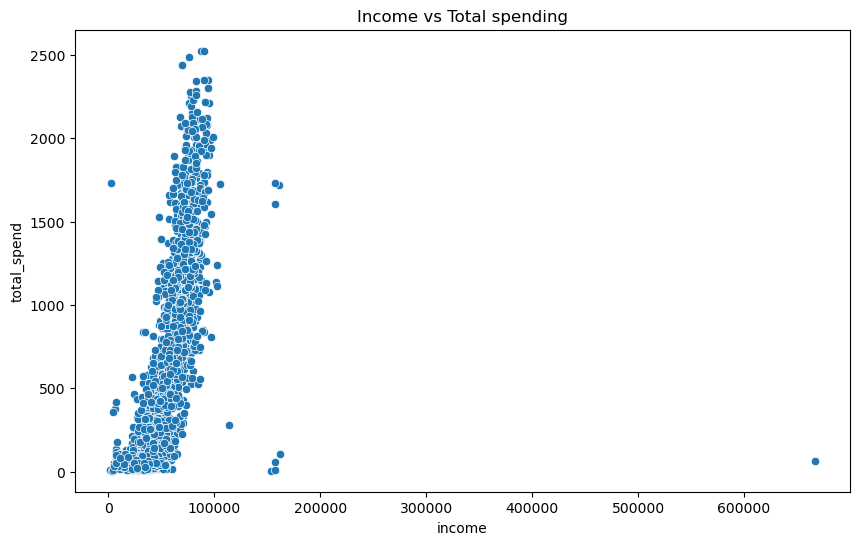

In [25]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=dff, x='income', y='total_spend')

plt.title('Income vs Total spending')
plt.show()

In [26]:
dff['income'].corr(dff['total_spend'])

np.float64(0.66751615890341)

a strong positive relationship was observed between customers income and total spending with r= 0.67. 
customers with higher income tend to spend more.

In [27]:
from scipy.stats import linregress

In [28]:
h1_df = dff.dropna(subset=['income']).copy()
h1_df

,id,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mntwines,...,numwebvisitsmonth,acceptedcmp3,acceptedcmp4,acceptedcmp5,acceptedcmp1,acceptedcmp2,complain,response,age,total_spend
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,1,57,1617
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,0,60,27
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,0,49,776
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,0,30,53
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,0,33,422
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,5,0,0,0,0,0,0,0,47,1341
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,7,0,0,0,1,0,0,0,68,444
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,6,0,1,0,0,0,0,0,33,1241
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,3,0,0,0,0,0,0,0,58,843


In [29]:
h1_df['income'].isna().sum()

np.int64(0)

In [30]:
slope, intercept, r_value, p_value, std_err = linregress(h1_df['income'],h1_df['total_spend'])

print('slope:', slope)
print("Intercept:", intercept)
print("R-value:", r_value)
print("R-squared:", r_value**2)
print("P-value:", p_value)
print("Std Error:", std_err)

slope: 0.015972725625463882
Intercept: -227.33889491221032
R-value: 0.66751615890341
R-squared: 0.4455778223971625
P-value: 1.662141320041757e-285
Std Error: 0.0003789162006674184


# Findnings 

- there is a strong positive relationship was found between customer income and total spending r=0.67.
- linear regression analysis showed that income alone explains around 44.6% of the variation in customer spending.
- the relationship was statistically significant  with p-value at 0.0001 indicating that its unlikely that the result is a random chance.
- for every additional 1000 dollars increase in income, customers were expected to increase their spending by around 16$.

# recommendation: 
- the company may focus on advertising premium quality product to higher earning customers in personalised marketing campaign and loyality programs as these customers generate higher spending levels.

# H2 campaign responders spend more than non responders.

In [31]:
dff

,id,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mntwines,...,numwebvisitsmonth,acceptedcmp3,acceptedcmp4,acceptedcmp5,acceptedcmp1,acceptedcmp2,complain,response,age,total_spend
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,1,57,1617
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,0,60,27
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,0,49,776
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,0,30,53
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,0,33,422
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,5,0,0,0,0,0,0,0,47,1341
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,7,0,0,0,1,0,0,0,68,444
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,6,0,1,0,0,0,0,0,33,1241
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,3,0,0,0,0,0,0,0,58,843


In [32]:
h2_df = dff[['response', 'total_spend']].copy()
h2_df.describe()

,response,total_spend
count,2237.000000,2237.000000
mean,0.149307,605.743406
std,0.356471,601.840466
min,0.000000,5.000000
25%,0.000000,69.000000
50%,0.000000,396.000000
75%,0.000000,1045.000000
max,1.000000,2525.000000


In [33]:
responders = h2_df[h2_df['response'] == 1]['total_spend']

non_responders = h2_df[h2_df['response'] == 0]['total_spend']

In [34]:
responders.describe()

count     334.000000
mean      987.392216
std       719.009695
min        17.000000
25%       252.000000
50%      1057.500000
75%      1617.000000
max      2525.000000
Name: total_spend, dtype: float64

In [35]:
non_responders.describe()

count    1903.000000
mean      538.759327
std       552.484926
min         5.000000
25%        62.000000
50%       315.000000
75%       955.000000
max      2525.000000
Name: total_spend, dtype: float64

In [36]:
t_stat, p_value = ttest_ind(responders, non_responders, equal_var=False)

print('t_stat:', t_stat)
print('p_value:', p_value)

t_stat: 10.854708080303885
p_value: 2.894434641330478e-24


# finding

- customers who responded to marketing campaigns spent 83% more than customer who didn't respond.
- t-test confirmed the finding and was statically significatn with t= 10.85 and p_value < 0.0001.

# H3 Do frequent website visitors convert into higher spending?

In [37]:
dff.columns

Index(['id', 'year_birth', 'education', 'marital_status', 'income', 'kidhome',
       'teenhome', 'dt_customer', 'recency', 'mntwines', 'mntfruits',
       'mntmeatproducts', 'mntfishproducts', 'mntsweetproducts',
       'mntgoldprods', 'numdealspurchases', 'numwebpurchases',
       'numcatalogpurchases', 'numstorepurchases', 'numwebvisitsmonth',
       'acceptedcmp3', 'acceptedcmp4', 'acceptedcmp5', 'acceptedcmp1',
       'acceptedcmp2', 'complain', 'response', 'age', 'total_spend'],
      dtype='object')

In [38]:
h3_df = dff[['numwebvisitsmonth', 'total_spend']].copy()
h3_df.describe()

,numwebvisitsmonth,total_spend
count,2237.000000,2237.000000
mean,5.319177,605.743406
std,2.426386,601.840466
min,0.000000,5.000000
25%,3.000000,69.000000
50%,6.000000,396.000000
75%,7.000000,1045.000000
max,20.000000,2525.000000


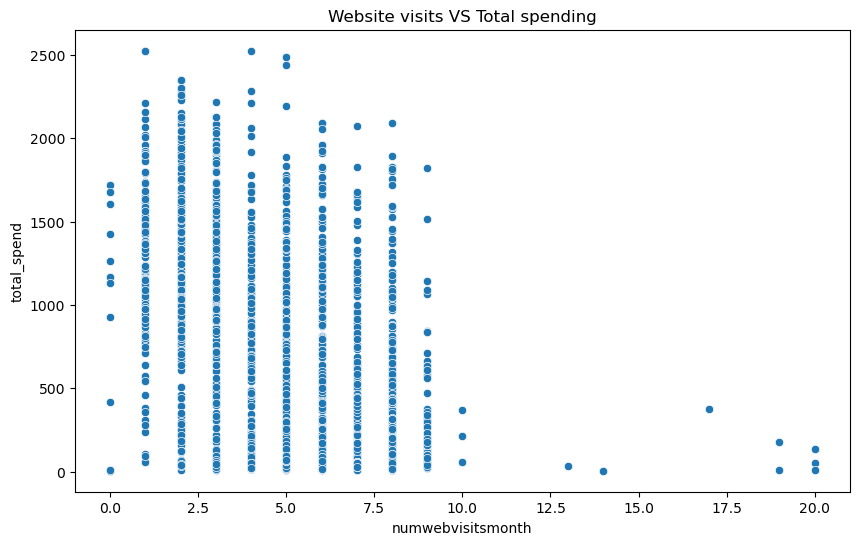

In [39]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=h3_df, x='numwebvisitsmonth', y='total_spend')

plt.title('Website visits VS Total spending')
plt.show()

In [40]:
from scipy.stats import pearsonr

In [41]:
corr, p_value = pearsonr(h3_df['numwebvisitsmonth'], h3_df['total_spend'])

print('Correlation:', corr)
print('P_value:', p_value)

Correlation: -0.49992182757042913
P_value: 9.105638942363131e-142


# findings

- a moderate negative relationship was observerd between number of website visits and total spending  with r=0.50 and the p_value < 0.0001.
- customers visiting the webstire more often tend to spend less overall and may indicate to comparison shopping or conversion inefficiences. 

# H4 Do marketing campaign response rates differ across customer segments?

In [42]:
h4_df = dff[['age', 'response']].copy()
h4_df

,age,response
0,57,1
1,60,0
2,49,0
3,30,0
4,33,0
...,...,...
2235,47,0
2236,68,0
2237,33,0
2238,58,0


In [43]:
h4_df['age_group'] = pd.cut(h4_df['age'], bins=[18,30,45,60,75],labels=['18-30','31-45','46-60','61-75'])
h4_df

,age,response,age_group
0,57,1,46-60
1,60,0,46-60
2,49,0,46-60
3,30,0,18-30
4,33,0,31-45
...,...,...,...
2235,47,0,46-60
2236,68,0,61-75
2237,33,0,31-45
2238,58,0,46-60


In [44]:
response_rate = h4_df.groupby('age_group')['response'].mean() * 100

response_rate

/var/folders/cr/wjvb_x0n2xjdtpg_vhz62xp40000gn/T/ipykernel_22946/1627921531.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  response_rate = h4_df.groupby('age_group')['response'].mean() * 100


age_group
18-30    17.898833
31-45    15.266393
46-60    12.907609
61-75    16.165414
Name: response, dtype: float64

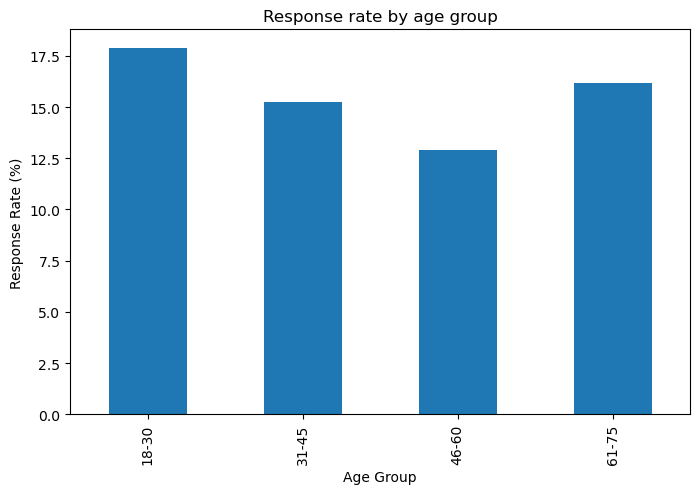

In [45]:
response_rate.plot(kind='bar', figsize=(8,5))

plt.title('Response rate by age group')
plt.xlabel('Age Group')
plt.ylabel('Response Rate (%)')

plt.show()

In [46]:
contingency = pd.crosstab(h4_df['age_group'], h4_df['response'])
contingency

response,0,1
age_group,,
18-30,211,46
31-45,827,149
46-60,641,95
61-75,223,43


In [47]:
from scipy.stats import chi2_contingency

In [48]:
chi2, p_value, dof, expected = chi2_contingency(contingency)

print("Chi-square:", chi2)
print("P-value:", p_value)

Chi-square: 4.566295934275484
P-value: 0.20645252411513607


# Finding

- the youngest customer segment showed the highest campaign response rate at 17.9%, while customers aged 46–60 showed the lowest response rate at 12.9%.
- the test was not statistically significant which indicates that campaign response rates do not differ significantly by age group.

In [49]:
dff

,id,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mntwines,...,numwebvisitsmonth,acceptedcmp3,acceptedcmp4,acceptedcmp5,acceptedcmp1,acceptedcmp2,complain,response,age,total_spend
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,1,57,1617
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,0,60,27
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,0,49,776
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,0,30,53
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,0,33,422
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,5,0,0,0,0,0,0,0,47,1341
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,7,0,0,0,1,0,0,0,68,444
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,6,0,1,0,0,0,0,0,33,1241
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,3,0,0,0,0,0,0,0,58,843


In [50]:
h4_dff = dff[['marital_status', 'response']].copy()

In [51]:
response = h4_dff.groupby('marital_status')['response'].mean() * 100
response

marital_status
Absurd      50.000000
Alone       33.333333
Divorced    20.779221
Married     11.342593
Single      22.129436
Together    10.362694
Widow       24.675325
YOLO        50.000000
Name: response, dtype: float64

In [52]:
status_count = (h4_dff['marital_status'].value_counts(normalize=True) * 100).round(2)

status_count

marital_status
Married     38.62
Together    25.88
Single      21.41
Divorced    10.33
Widow        3.44
Alone        0.13
Absurd       0.09
YOLO         0.09
Name: proportion, dtype: float64

In [53]:
h4_dff = h4_dff[~h4_dff['marital_status'].isin(['Alone', 'Absurd', 'YOLO'])]

In [54]:
response = h4_dff.groupby('marital_status')['response'].mean() * 100
response

marital_status
Divorced    20.779221
Married     11.342593
Single      22.129436
Together    10.362694
Widow       24.675325
Name: response, dtype: float64

Text(0, 0.5, 'Response')

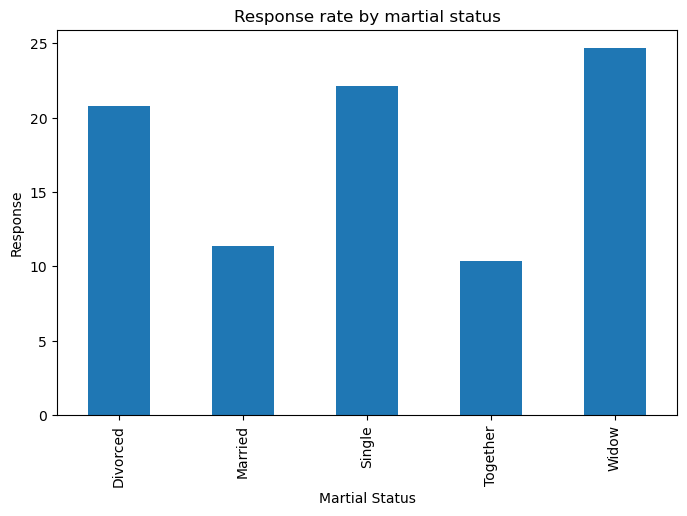

In [55]:
response.plot(kind='bar', figsize=(8,5))

plt.title('Response rate by martial status')
plt.xlabel('Martial Status')
plt.ylabel('Response')

In [56]:
cont = pd.crosstab(h4_dff['marital_status'], h4_dff['response'])
cont

response,0,1
marital_status,,
Divorced,183,48
Married,766,98
Single,373,106
Together,519,60
Widow,58,19


In [57]:
chi2, p_value, dof, expected = chi2_contingency(cont)

print('Chi2:', chi2)
print('p_value:', p_value)

Chi2: 50.01946313149577
p_value: 3.577234883897916e-10


# findings

- campaign response across martial status groups varied significantly single, divorced and widowed customers showed higher response rates than customers who are married or toghter. which may suggest that customers without a partner may have different purchase motivations. 

In [58]:
hh4_df = dff[['kidhome', 'teenhome', 'response']].copy()

In [59]:
hh4_df['children'] = hh4_df['kidhome'] + hh4_df['teenhome']

In [60]:
hh4_df

,kidhome,teenhome,response,children
0,0,0,1,0
1,1,1,0,2
2,0,0,0,0
3,1,0,0,1
4,1,0,0,1
...,...,...,...,...
2235,0,1,0,1
2236,2,1,0,3
2237,0,0,0,0
2238,0,1,0,1


In [61]:
child_home = hh4_df.groupby('children')['response'].mean() * 100
child_home

children
0    26.530612
1    10.301954
2    11.163895
3     3.773585
Name: response, dtype: float64

In [62]:
teen_response = hh4_df.groupby('teenhome')['response'].mean() * 100
teen_response

teenhome
0    20.501730
1     8.940719
2     9.615385
Name: response, dtype: float64

In [63]:
kid_response = hh4_df.groupby('kidhome')['response'].mean() * 100
kid_response

kidhome
0    17.195972
1    12.249443
2     4.166667
Name: response, dtype: float64

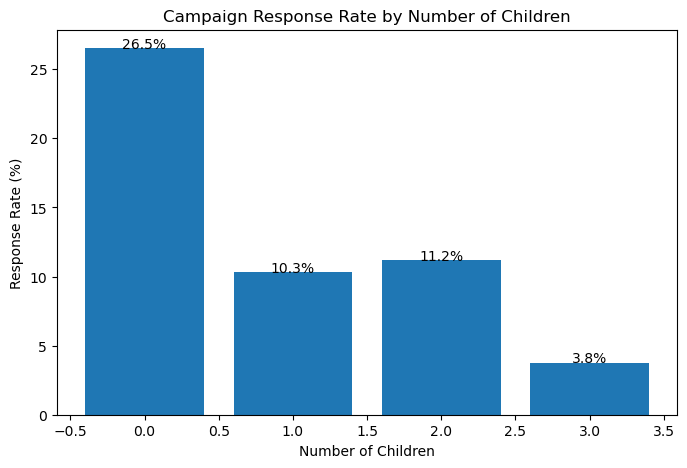

In [64]:
response_by_children = (hh4_df.groupby('children')['response'].mean().mul(100).reset_index())

plt.figure(figsize=(8,5))

bars = plt.bar(response_by_children['children'],response_by_children['response'])

plt.title('Campaign Response Rate by Number of Children')
plt.xlabel('Number of Children')
plt.ylabel('Response Rate (%)')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,bar.get_height(),
             f'{bar.get_height():.1f}%',ha='center')

plt.show()

In [65]:
contingency = pd.crosstab(hh4_df['children'],hh4_df['response'])

In [66]:
chi2, p_value, dof, expected = chi2_contingency(contingency)

print("Chi-square:", chi2)
print("P-value:", p_value)

Chi-square: 96.37427356172887
P-value: 9.353006170362646e-21


# Findings

- customers without children tend to respond moredrequently to marketing campaigns meanwhile resposne rate decline substantially once children is present in the household.

# recommendation
- the company should prioritize targeting child free households.
- the company might need different compaign messaging to housholds with children rather than the generic campaign.


# H5 Are there discount-dependent customers?

In [67]:
dff

,id,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mntwines,...,numwebvisitsmonth,acceptedcmp3,acceptedcmp4,acceptedcmp5,acceptedcmp1,acceptedcmp2,complain,response,age,total_spend
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,1,57,1617
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,0,60,27
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,0,49,776
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,0,30,53
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,0,33,422
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,5,0,0,0,0,0,0,0,47,1341
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,7,0,0,0,1,0,0,0,68,444
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,6,0,1,0,0,0,0,0,33,1241
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,3,0,0,0,0,0,0,0,58,843


In [68]:
dff['numdealspurchases'].describe()

count    2237.000000
mean        2.326777
std         1.932923
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        15.000000
Name: numdealspurchases, dtype: float64

In [73]:
dff['numdealspurchases'].value_counts().sort_index()

numdealspurchases
0      46
1     967
2     497
3     297
4     189
5      94
6      61
7      40
8      14
9       8
10      5
11      5
12      4
13      3
15      7
Name: count, dtype: int64

In [74]:
dff['deal_segment'] = pd.cut(dff['numdealspurchases'],bins=[-1,2,5,15],labels=['Low Deal Buyer','Medium Deal Buyer',
                                                                             'High Deal Buyer'])

In [75]:
response_rate = (dff.groupby('deal_segment')['response'].mean() * 100)

print(response_rate)

deal_segment
Low Deal Buyer       14.834437
Medium Deal Buyer    13.793103
High Deal Buyer      20.408163
Name: response, dtype: float64


/var/folders/cr/wjvb_x0n2xjdtpg_vhz62xp40000gn/T/ipykernel_22946/1615263728.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  response_rate = (dff.groupby('deal_segment')['response'].mean() * 100)


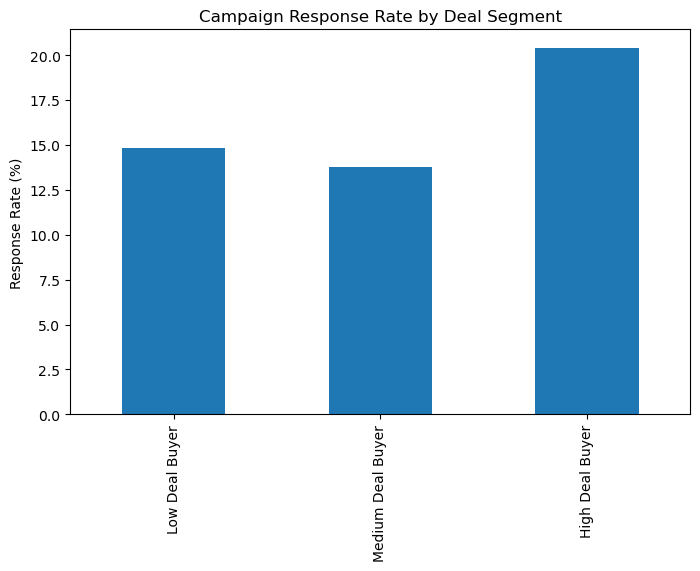

In [76]:
response_rate.plot(kind='bar',figsize=(8,5))

plt.title('Campaign Response Rate by Deal Segment')
plt.ylabel('Response Rate (%)')
plt.xlabel('')
plt.show()

In [78]:
contingency = pd.crosstab(dff['deal_segment'],dff['response'])
contingency

response,0,1
deal_segment,,
Low Deal Buyer,1286,224
Medium Deal Buyer,500,80
High Deal Buyer,117,30


In [80]:
chi2,p,dof,expected = chi2_contingency(contingency)

print("Chi-square:",chi2)
print("P-value:",p)

Chi-square: 4.074313146453838
P-value: 0.1303989641407659


In [81]:
dff.groupby('deal_segment')['total_spend'].mean()

/var/folders/cr/wjvb_x0n2xjdtpg_vhz62xp40000gn/T/ipykernel_22946/3095594695.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dff.groupby('deal_segment')['total_spend'].mean()


deal_segment
Low Deal Buyer       640.498013
Medium Deal Buyer    499.650000
High Deal Buyer      667.340136
Name: total_spend, dtype: float64

# finding

- high deal buyer should a slighty higher campaign response rate than low and medium deal buyers.
- the difference wasnt statistically significant therefore no clear evidence was found that deal purchase behavour influence campaign resposne rate.

# H6 What customer characteristics are associated with campaign acceptance?

In [82]:
dff

,id,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mntwines,...,acceptedcmp3,acceptedcmp4,acceptedcmp5,acceptedcmp1,acceptedcmp2,complain,response,age,total_spend,deal_segment
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,0,0,0,1,57,1617,Medium Deal Buyer
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,0,0,0,0,60,27,Low Deal Buyer
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,0,0,0,0,49,776,Low Deal Buyer
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,0,0,0,0,0,30,53,Low Deal Buyer
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,0,0,0,0,33,422,Medium Deal Buyer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,0,0,0,0,0,0,0,47,1341,Low Deal Buyer
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,0,0,0,1,0,0,0,68,444,High Deal Buyer
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,0,1,0,0,0,0,0,33,1241,Low Deal Buyer
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,0,0,0,0,0,0,0,58,843,Low Deal Buyer


In [83]:
dff['children'] = (dff['kidhome'] + dff['teenhome'])
dff

,id,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mntwines,...,acceptedcmp4,acceptedcmp5,acceptedcmp1,acceptedcmp2,complain,response,age,total_spend,deal_segment,children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,0,0,1,57,1617,Medium Deal Buyer,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,0,0,0,60,27,Low Deal Buyer,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,0,0,0,49,776,Low Deal Buyer,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,0,0,0,0,30,53,Low Deal Buyer,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,0,0,0,33,422,Medium Deal Buyer,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,0,0,0,0,0,0,47,1341,Low Deal Buyer,1
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,0,0,1,0,0,0,68,444,High Deal Buyer,3
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,1,0,0,0,0,0,33,1241,Low Deal Buyer,0
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,0,0,0,0,0,0,58,843,Low Deal Buyer,1


In [84]:
responders = dff[dff['response']==1]
non_responders = dff[dff['response']==0]

In [85]:
responders[['income','age','children','total_spend']].mean()

income         60209.675676
age               44.583832
children           0.646707
total_spend      987.392216
dtype: float64

In [86]:
non_responders[['income','age','children','total_spend']].mean()

income         50824.326064
age               45.188650
children           1.004204
total_spend      538.759327
dtype: float64

In [87]:
comparison = pd.DataFrame({'Responders': responders[['income','age','children','total_spend']].mean(),
                           'Non-Responders': non_responders[['income','age','children','total_spend']].mean()})

comparison

,Responders,Non-Responders
income,60209.675676,50824.326064
age,44.583832,45.188650
children,0.646707,1.004204
total_spend,987.392216,538.759327


In [88]:
dff = dff[~dff['marital_status'].isin(['Alone', 'Absurd', 'YOLO'])]

In [89]:
campaigns = ['acceptedcmp1','acceptedcmp2','acceptedcmp3','acceptedcmp4','acceptedcmp5']

In [93]:
campaign_summary = pd.DataFrame()

for campaign in campaigns:

    response_rate = (
        pd.crosstab(
            dff['marital_status'],
            dff[campaign],
            normalize='index'
        )[1] * 100
    )

    campaign_summary[campaign] = response_rate

campaign_summary.round(2)

,acceptedcmp1,acceptedcmp2,acceptedcmp3,acceptedcmp4,acceptedcmp5
marital_status,,,,,
Divorced,5.19,2.16,8.66,7.79,5.63
Married,7.29,0.81,7.29,7.29,7.64
Single,6.47,1.04,7.93,6.89,6.47
Together,5.53,2.07,6.39,7.43,7.43
Widow,6.49,1.30,5.19,12.99,10.39


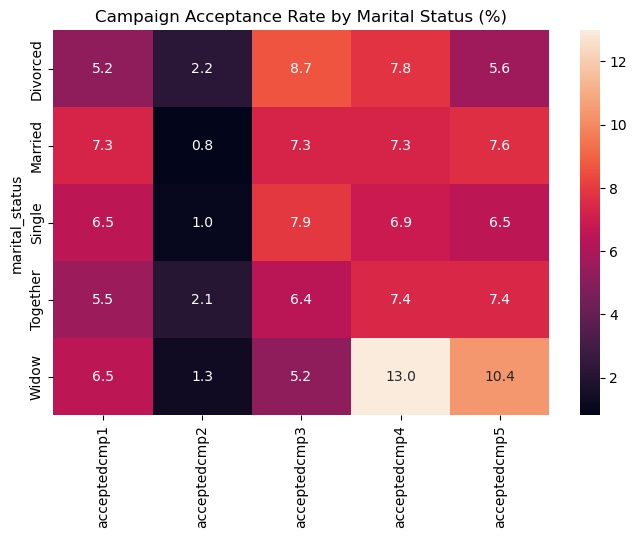

In [94]:
plt.figure(figsize=(8,5))

sns.heatmap(campaign_summary,annot=True,fmt=".1f")

plt.title('Campaign Acceptance Rate by Marital Status (%)')
plt.show()

In [95]:
for campaign in campaigns:
    
    table = pd.crosstab(dff['marital_status'],
        dff[campaign])

    chi2, p, dof, expected = chi2_contingency(table)

    print(campaign, round(p,4))

acceptedcmp1 0.6547
acceptedcmp2 0.2253
acceptedcmp3 0.7117
acceptedcmp4 0.4495
acceptedcmp5 0.6105


# findings
- marital status has a significant relationship with the latest campaign response (p < 0.001).
- single, divorced and widowed customers showed higher response rates than married and partnered customers, However, no significant differences were found across historical campaigns (AcceptedCmp1–5).

# recommnedations
- investigate the difference between the last campaign and the historical campagins.
- consider testing compaign messaging tailored to customers living alone as they appear more responsive to marketing campaigns. 

In [96]:
profile_diff = comparison.copy()

profile_diff['difference_pct'] = ((profile_diff['Responders'] - profile_diff['Non-Responders']) / profile_diff['Non-Responders'] * 100)

profile_diff

,Responders,Non-Responders,difference_pct
income,60209.675676,50824.326064,18.466255
age,44.583832,45.188650,-1.338427
children,0.646707,1.004204,-35.600071
total_spend,987.392216,538.759327,83.271484


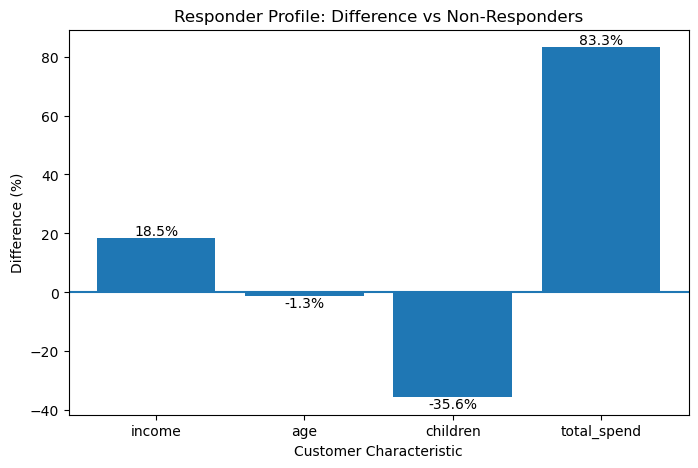

In [98]:
plt.figure(figsize=(8,5))

bars = plt.bar( profile_diff.index,profile_diff['difference_pct'])

plt.title('Responder Profile: Difference vs Non-Responders')
plt.ylabel('Difference (%)')
plt.xlabel('Customer Characteristic')

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():.1f}%',
        ha='center',
        va='bottom' if bar.get_height() >= 0 else 'top'
    )

plt.axhline(0)

plt.show()

# Finding

- Campaign responders spend 83.3% more, have 18.5% higher income, and have 35.6% fewer children on average than non responders, age difference is minimal.

# recommendation

- campaign targeting should prioritize higher income and higherspending customers with fewer household responsibilities.

In [100]:
dff.to_csv('data_frame.csv')